In [6]:
pip install xlrd


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


正在读取文件: 销售出库表.xlsx


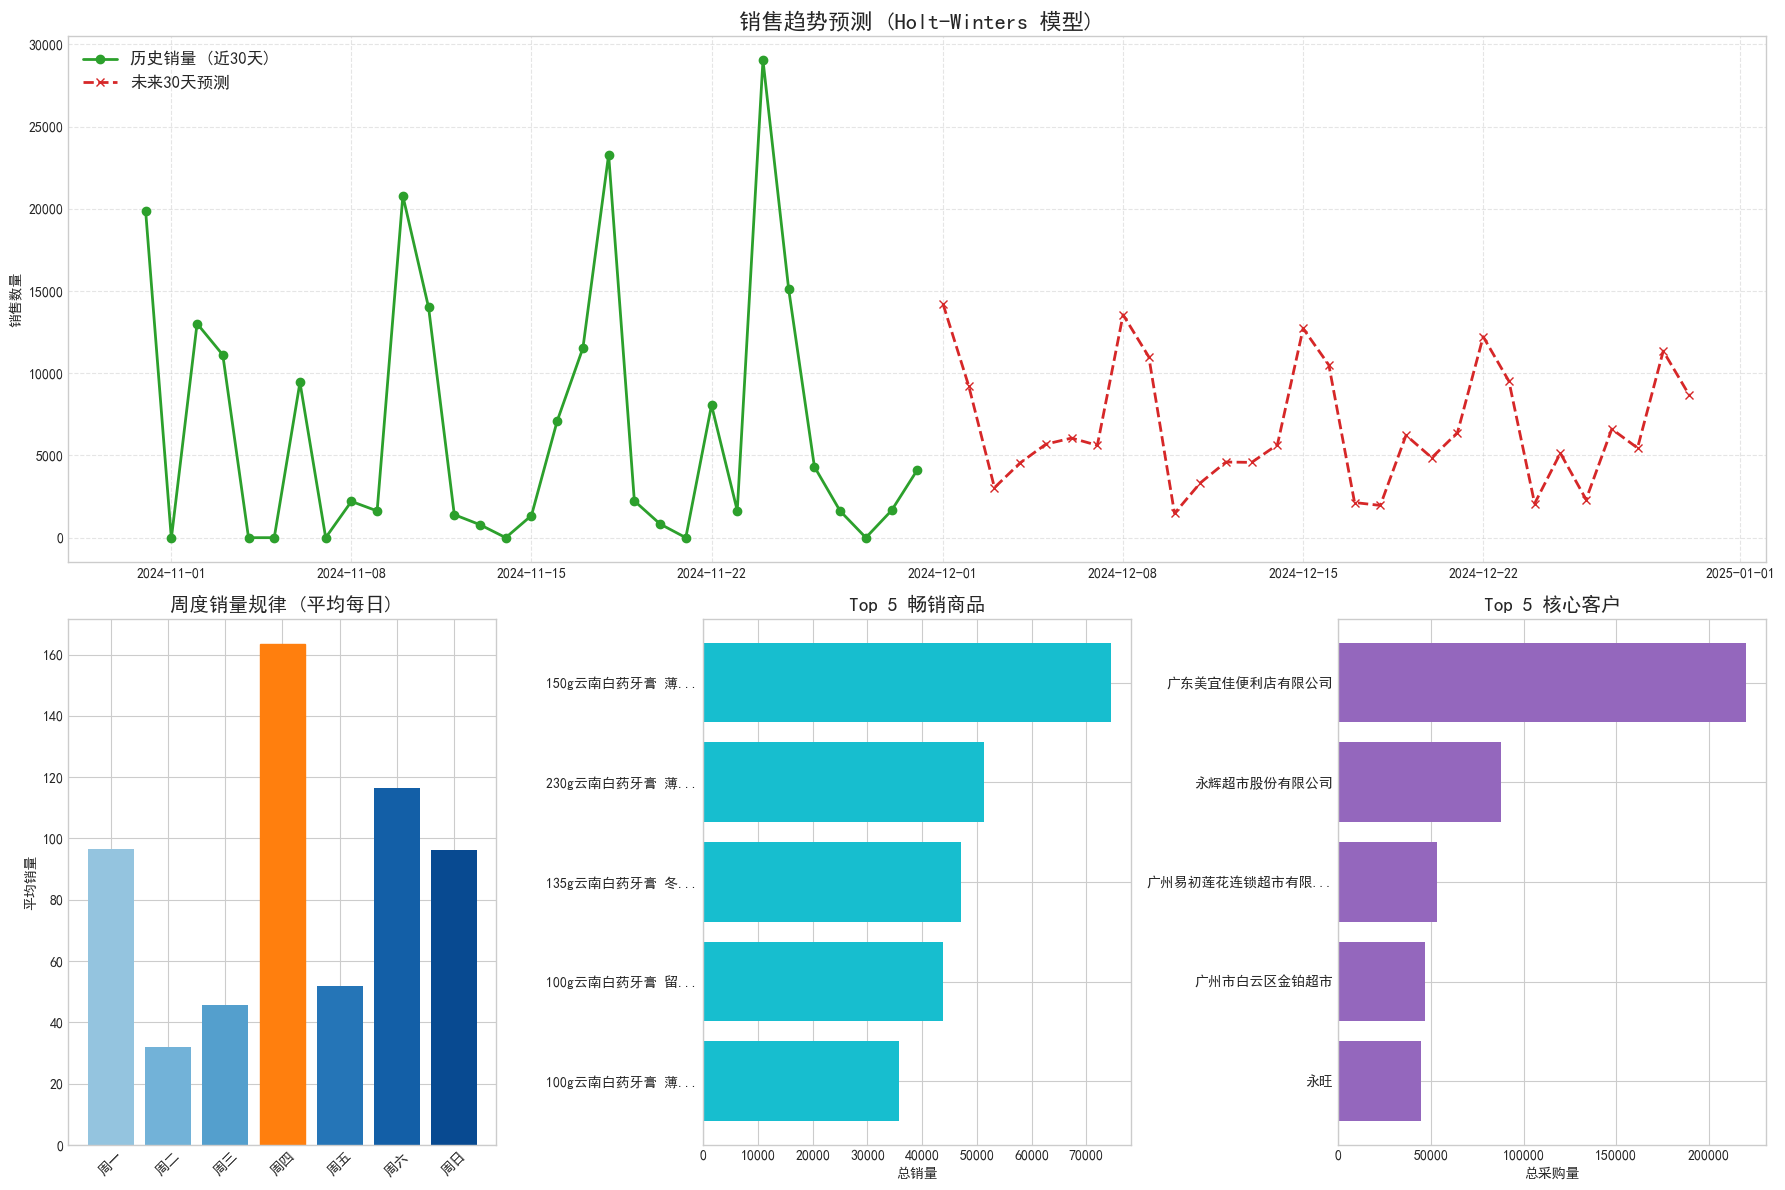

数据分析看板已生成。


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
import os

# ---------------------------------------------------------
# 1. 环境设置
# ---------------------------------------------------------
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
# 设置中文字体，确保图表文字不乱码
# 如果您的电脑没有这些字体，代码会自动回退到默认字体，建议安装SimHei
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'PingFang SC', 'Heiti TC']
plt.rcParams['axes.unicode_minus'] = False

# ---------------------------------------------------------
# 2. 读取数据
# ---------------------------------------------------------
file_path = '销售出库表.xlsx - Sheet1.csv'

# 自动寻找文件
if not os.path.exists(file_path):
    candidates = [f for f in os.listdir('.') if '销售' in f and (f.endswith('.csv') or f.endswith('.xlsx'))]
    if candidates:
        file_path = candidates[0]

print(f"正在读取文件: {file_path}")

try:
    df = pd.read_csv(file_path, encoding='utf-8', sep=',', on_bad_lines='skip')
except:
    try:
        df = pd.read_csv(file_path, encoding='gb18030', sep=',', on_bad_lines='skip')
    except:
        try:
            df = pd.read_excel(file_path)
        except Exception as e:
            print(f"文件读取失败: {e}")
            df = pd.DataFrame()

# ---------------------------------------------------------
# 3. 数据处理与分析
# ---------------------------------------------------------
if not df.empty:
    df.columns = [c.strip() for c in df.columns]
    
    if '日期' in df.columns and '实发数量' in df.columns:
        df['日期'] = pd.to_datetime(df['日期'], errors='coerce')
        df = df.dropna(subset=['日期'])
        df = df.sort_values('日期')
        
        # (A) 时间序列数据 (用于预测)
        daily_quantity = df.groupby('日期')['实发数量'].sum()
        daily_quantity = daily_quantity.asfreq('D').fillna(0)
        
        # (B) 周度分析数据
        df_analysis = df.copy()
        df_analysis['Weekday'] = df_analysis['日期'].dt.day_name()
        week_map = {
            'Monday': '周一', 'Tuesday': '周二', 'Wednesday': '周三', 
            'Thursday': '周四', 'Friday': '周五', 'Saturday': '周六', 'Sunday': '周日'
        }
        df_analysis['Weekday_CN'] = df_analysis['Weekday'].map(week_map)
        
        # 计算周一到周日的日均销量
        weekday_avg = df_analysis.groupby('Weekday_CN')['实发数量'].mean()
        week_order = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']
        weekday_avg = weekday_avg.reindex(week_order)
        
        # (C) Top 榜单数据 (取前5名并排序，方便画横向柱状图)
        top_products = df.groupby('产品名称')['实发数量'].sum().nlargest(5).sort_values(ascending=True)
        top_customers = df.groupby('购货单位')['实发数量'].sum().nlargest(5).sort_values(ascending=True)

        # ---------------------------------------------------------
        # 4. Holt-Winters 预测建模
        # ---------------------------------------------------------
        try:
            train_data = daily_quantity
            model = ExponentialSmoothing(
                train_data, 
                seasonal_periods=7, 
                trend='add', 
                seasonal='add', 
                damped_trend=True
            ).fit()

            forecast_days = 30
            forecast = model.forecast(forecast_days)
            std_dev = train_data.std()
            noise = np.random.normal(0, std_dev * 0.15, forecast_days) 
            forecast_adjusted = forecast + noise
            forecast_adjusted[forecast_adjusted < 0] = 0
            
            # ---------------------------------------------------------
            # 5. 绘制综合看板
            # ---------------------------------------------------------
            fig = plt.figure(figsize=(18, 12))
            
            # 布局: 2行3列
            # 第一行: 预测大图 (跨3列)
            ax1 = plt.subplot2grid((2, 3), (0, 0), colspan=3)
            # 第二行: 周度分析, Top产品, Top客户
            ax2 = plt.subplot2grid((2, 3), (1, 0))
            ax3 = plt.subplot2grid((2, 3), (1, 1))
            ax4 = plt.subplot2grid((2, 3), (1, 2))
            
            # --- 图1: 预测趋势 ---
            # 只展示最近30天历史 + 未来30天预测
            display_start = daily_quantity.index.max() - pd.DateOffset(days=30)
            plot_hist = daily_quantity[display_start:]
            
            ax1.plot(plot_hist.index, plot_hist.values, label='历史销量 (近30天)', color='#2ca02c', marker='o', linewidth=2)
            ax1.plot(forecast_adjusted.index, forecast_adjusted.values, label='未来30天预测', color='#d62728', linestyle='--', marker='x', linewidth=2)
            ax1.set_title('销售趋势预测 (Holt-Winters 模型)', fontsize=16, fontweight='bold')
            ax1.set_ylabel('销售数量')
            ax1.legend(loc='upper left', fontsize=12)
            ax1.grid(True, linestyle='--', alpha=0.5)
            
            # --- 图2: 周度销量规律 ---
            # 使用渐变色
            colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(weekday_avg)))
            bars = ax2.bar(weekday_avg.index, weekday_avg.values, color=colors)
            ax2.set_title('周度销量规律 (平均每日)', fontsize=14, fontweight='bold')
            ax2.set_ylabel('平均销量')
            ax2.tick_params(axis='x', rotation=45)
            # 高亮最大的一天
            max_idx = np.argmax(weekday_avg.values)
            bars[max_idx].set_color('#ff7f0e') # 橙色高亮
            
            # --- 图3: Top 5 产品 ---
            ax3.barh(top_products.index, top_products.values, color='#17becf')
            ax3.set_title('Top 5 畅销商品', fontsize=14, fontweight='bold')
            ax3.set_xlabel('总销量')
            # 截断过长的名称
            labels_prod = [l[:12] + '...' if len(str(l)) > 12 else str(l) for l in top_products.index]
            ax3.set_yticklabels(labels_prod)
            
            # --- 图4: Top 5 客户 ---
            ax4.barh(top_customers.index, top_customers.values, color='#9467bd')
            ax4.set_title('Top 5 核心客户', fontsize=14, fontweight='bold')
            ax4.set_xlabel('总采购量')
            labels_cust = [l[:12] + '...' if len(str(l)) > 12 else str(l) for l in top_customers.index]
            ax4.set_yticklabels(labels_cust)
            
            plt.tight_layout()
            plt.show()
            
            print("数据分析看板已生成。")

        except Exception as e:
            print(f"建模或绘图过程出错: {e}")
    else:
        print("缺少必要的列: '日期' 或 '实发数量'")
else:
    print("数据加载失败或为空")